# Review NLP Analysis — Sentiment & Theme Tagging

`data/processed/reviews.csv` contains 3,898 real, substantive guest reviews
(median 127 characters, up to 5,402) covering 520 of 1,556 listings (~33%).
This notebook explores what `src/airbnb_pipeline/stages/review_nlp.py`
computed: a VADER sentiment score per review, and presence tags for 5
operationally meaningful themes (cleanliness, host communication, value for
money, location, maintenance/amenities).

**Method notes, stated plainly:**
- Sentiment (VADER) is lexicon-based, not a trained model — well-suited to
  short informal review text, handles negation/intensifiers reasonably.
- Theme tags are keyword-category matching, not topic modeling — they flag
  *what's discussed*, not *whether that specific mention was positive or
  negative* (no per-theme sentiment / negation handling). The keyword lists
  were iteratively validated against real review samples before use (an
  earlier, narrower list missed things like "friendly host" and "great
  hospitality" — see the theme_keywords history in review_nlp.py's
  docstring).

**Provenance — where `sentiment_score` and the `theme_*` columns actually
come from**: this notebook does **not** compute them. It only reads and
analyzes the already-enriched `data/processed/reviews.csv`. The actual
computation is:
- `score_sentiment()` / `tag_themes()` / `enrich_reviews()` in
  `src/airbnb_pipeline/stages/review_nlp.py`
- invoked by `run_pipeline.py`, stage 5/5 ("review NLP: sentiment + theme
  tags"), which is what writes those columns into
  `data/processed/reviews.csv`

To regenerate with updated logic, edit `review_nlp.py` and re-run
`python run_pipeline.py` — then re-run this notebook to see the new
results. Running this notebook alone will *not* pick up code changes to
`review_nlp.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

reviews = pd.read_csv("../data/processed/reviews.csv", parse_dates=["review_date"])
listings = pd.read_csv("../final_data/listings.csv")

theme_cols = [c for c in reviews.columns if c.startswith("theme_")]
print(f"reviews: {reviews.shape}, themes: {theme_cols}")

reviews: (3898, 12), themes: ['theme_cleanliness', 'theme_host_communication', 'theme_value_price', 'theme_location', 'theme_maintenance_amenities']


## 1. Sentiment overview

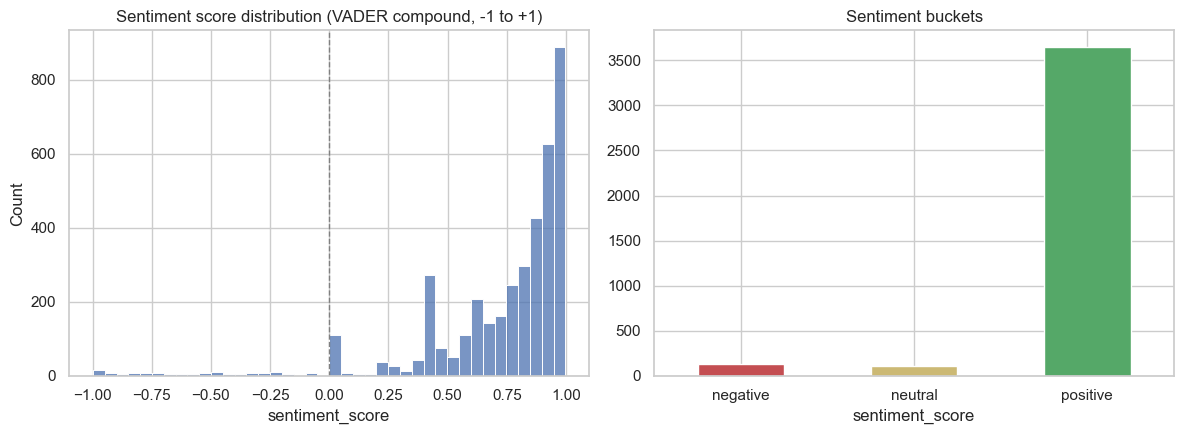

count    3897.000
mean        0.719
std         0.340
min        -0.998
25%         0.625
50%         0.847
75%         0.942
max         0.998
Name: sentiment_score, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(reviews["sentiment_score"].dropna(), bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Sentiment score distribution (VADER compound, -1 to +1)")
axes[0].axvline(0, color="grey", linestyle="--", linewidth=1)

buckets = pd.cut(
    reviews["sentiment_score"], bins=[-1, -0.05, 0.05, 1], labels=["negative", "neutral", "positive"]
).value_counts().reindex(["negative", "neutral", "positive"])
buckets.plot.bar(ax=axes[1], color=["#C44E52", "#CCB974", "#55A868"])
axes[1].set_title("Sentiment buckets")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(reviews["sentiment_score"].describe().round(3))

**Reading this**: reviews skew strongly positive (93.6% positive, only
3.5% negative) — consistent with how Airbnb reviews generally behave
(dissatisfied guests more often just don't rebook than leave a scathing
review). This means sentiment here is more useful for spotting *relative*
differences and specific complaints than for a headline "guests are happy"
statistic, which would be true almost everywhere by default.

## 2. What guests actually talk about

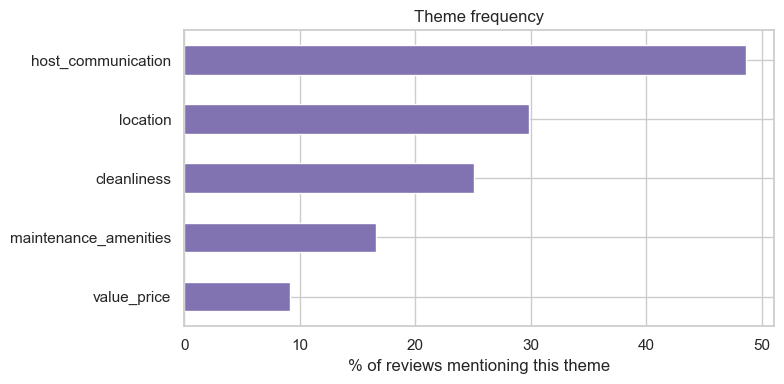

value_price               9.1
maintenance_amenities    16.5
cleanliness              25.0
location                 29.8
host_communication       48.6
dtype: float64

In [3]:
theme_freq = pd.Series({c.replace("theme_", ""): reviews[c].mean() * 100 for c in theme_cols}).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
theme_freq.plot.barh(ax=ax, color="#8172B2")
ax.set_xlabel("% of reviews mentioning this theme")
ax.set_title("Theme frequency")
plt.tight_layout()
plt.show()

theme_freq.round(1)

In [4]:
print("Average sentiment: reviews that mention a theme vs. those that don't\n")
for c in theme_cols:
    with_theme = reviews[reviews[c]]["sentiment_score"].mean()
    without_theme = reviews[~reviews[c]]["sentiment_score"].mean()
    print(f"{c.replace('theme_', ''):<24} with={with_theme:.3f}   without={without_theme:.3f}   diff={with_theme-without_theme:+.3f}")

Average sentiment: reviews that mention a theme vs. those that don't

cleanliness              with=0.781   without=0.698   diff=+0.083
host_communication       with=0.845   without=0.599   diff=+0.246
value_price              with=0.713   without=0.719   diff=-0.006
location                 with=0.828   without=0.673   diff=+0.155
maintenance_amenities    with=0.747   without=0.713   diff=+0.034


**Reading this**: mentioning the host (`host_communication`) or
`location` correlates with *meaningfully higher* sentiment than average —
these are common praise triggers in this dataset, not complaint triggers.
`value_price` shows almost no difference either way — price gets mentioned
in both good and bad reviews about equally. This is a correlation from
presence-tagging, not proof of causation (remember: no per-theme sentiment
here) — but it's a reasonable signal for which levers matter most to guest
satisfaction.

## 3. Sentiment trend over time

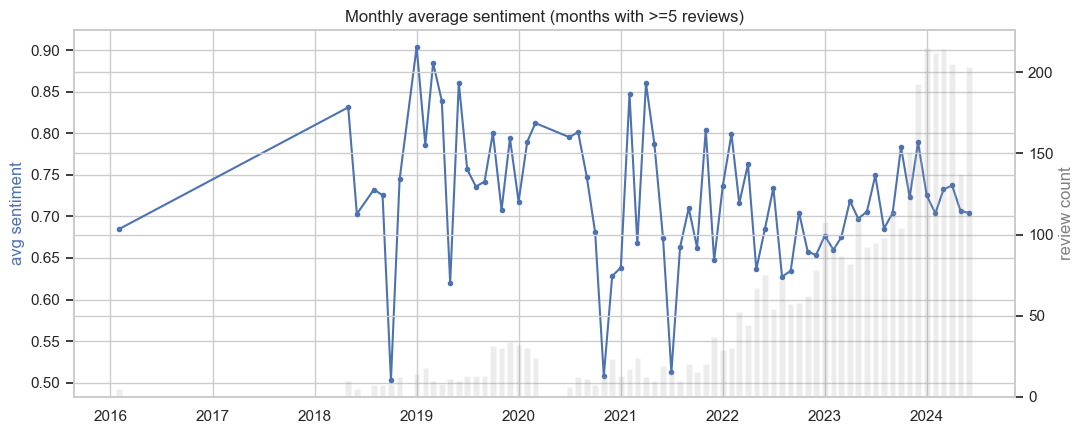

In [5]:
monthly = reviews.set_index("review_date")["sentiment_score"].resample("MS").agg(["mean", "count"])
monthly = monthly[monthly["count"] >= 5]  # drop months with too few reviews to be meaningful

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(monthly.index, monthly["mean"], color="#4C72B0", marker="o", markersize=3)
ax1.set_ylabel("avg sentiment", color="#4C72B0")
ax1.set_title("Monthly average sentiment (months with >=5 reviews)")

ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly["count"], alpha=0.15, color="grey", width=20)
ax2.set_ylabel("review count", color="grey")

plt.tight_layout()
plt.show()

**Reading this**: sentiment has stayed relatively stable (roughly 0.68-0.79)
through the review-volume ramp-up into mid-2024 — growth in listings/reviews
hasn't come with a decline in guest satisfaction, a reasonable sign for
market health rather than a "growing too fast, quality dropping" pattern.

## 4. By division (sample-size caveat applies, same as everywhere else in this project)

In [6]:
VALID_BD = ["Dhaka Division", "Chittagong", "Sylhet Division", "Rajshahi Division",
            "Barisal Division", "Khulna Division", "Rangpur Division", "Mymensingh Division"]

merged = reviews.merge(listings[["base_urls", "principalSubdivision", "localityName"]], on="base_urls", how="left")
bd_merged = merged[merged["principalSubdivision"].isin(VALID_BD)]

div_sentiment = bd_merged.groupby("principalSubdivision")["sentiment_score"].agg(["count", "mean"]).round(3)
div_sentiment.columns = ["review_count", "avg_sentiment"]
div_sentiment.sort_values("review_count", ascending=False)

,review_count,avg_sentiment
principalSubdivision,,
Dhaka Division,2845,0.712
Chittagong,250,0.749
Khulna Division,29,0.728
Sylhet Division,18,0.872
Rajshahi Division,13,0.713
Mymensingh Division,4,0.667
Barisal Division,2,0.930
Rangpur Division,1,0.891


Only Dhaka (2,845 reviews) and Chittagong (250) have enough review volume
to trust a division-level sentiment average — everything else has under 30
reviews, several under 5. Same pattern as price/rating throughout this
project: don't read those thin rows as reliable signals.

## 5. Dhaka neighborhoods: sentiment + themes side by side

In [7]:
DENSE_NEIGHBORHOODS = ["Gulshan", "Mohammadpur", "Dhanmondi", "Bashundhara Residential Area",
                        "Uttara", "Khilgaon", "Kuril", "Kalabagan"]
dhaka_reviews = merged[merged["localityName"].isin(DENSE_NEIGHBORHOODS)]

nb_summary = dhaka_reviews.groupby("localityName").agg(
    reviews=("sentiment_score", "count"),
    avg_sentiment=("sentiment_score", "mean"),
)
for c in theme_cols:
    nb_summary[c.replace("theme_", "pct_")] = dhaka_reviews.groupby("localityName")[c].mean() * 100

nb_summary.round(2).sort_values("reviews", ascending=False)

,reviews,avg_sentiment,pct_cleanliness,pct_host_communication,pct_value_price,pct_location,pct_maintenance_amenities
localityName,,,,,,,
Gulshan,755,0.74,26.46,50.40,8.47,36.77,19.84
Dhanmondi,260,0.74,21.15,50.38,5.00,33.08,16.15
Uttara,254,0.72,26.77,39.37,11.02,30.31,12.99
Kuril,231,0.52,23.81,33.77,11.69,16.02,14.29
Mohammadpur,215,0.68,28.37,36.28,5.12,23.26,13.49
Bashundhara Residential Area,134,0.76,27.61,50.75,5.97,19.40,18.66
Kalabagan,75,0.71,25.33,57.33,5.33,50.67,25.33
Khilgaon,51,0.76,9.80,62.75,11.76,13.73,15.69


**Cross-check against the earlier Dhaka deep-dive notebook**: Gulshan has
both the most reviews (755) here and the highest review *velocity* there —
consistent, independently-derived signals. Kalabagan is lowest on both
counts (75 reviews here, lowest velocity there) — reinforces the earlier
"thin demand evidence" caution flag rather than being a one-off artifact of
either method.

## 6. What guests specifically complain about

In [8]:
negative = reviews[reviews["sentiment_score"] < -0.3].sort_values("sentiment_score")
print(f"{len(negative)} reviews with clearly negative sentiment (score < -0.3)\n")

for _, row in negative.head(10).iterrows():
    tags = [c.replace("theme_", "") for c in theme_cols if row[c]]
    print(f"[{row['sentiment_score']:.2f}] tags={tags}")
    print(f"  {str(row['rating_comment'])[:220]}")
    print()

102 reviews with clearly negative sentiment (score < -0.3)

[-1.00] tags=['cleanliness', 'host_communication', 'location', 'maintenance_amenities']
  I booked this listing from Airbnb for 31 nights from the UK. I chose this property based on the tag “super host” and “premium property” and reviews. But I must admit it was the biggest disappointment I have faced for thi

[-0.98] tags=['cleanliness', 'location', 'maintenance_amenities']
  I have stayed at nearly 100 Airbnb locations, but my experience at this Airbnb was particularly troubling. Despite positive initial impressions from photos, my experience was marked by numerous issues:
Strike 1: Visa co

[-0.98] tags=['cleanliness', 'location', 'maintenance_amenities']
  Suddenly at midnight, the apartment was blacked out and terrible burning smell everywhere. Soon it was found that the apartment caught electrical fire from faulty wiring. We were terrified as hell. Owner came and mention

[-0.98] tags=['host_communication']
  Our Airbnb 

## Summary

- Sentiment skews strongly positive overall (93.6%), as expected for Airbnb
  reviews generally — the useful signal here is *relative* differences and
  specific complaint text, not a headline satisfaction number.
- Host communication is both the most-discussed theme (48.6% of reviews)
  and the one most associated with higher sentiment (+0.25 vs. reviews that
  don't mention it) — the clearest lever for guest satisfaction in this
  dataset.
- Sentiment has held steady through the review-volume ramp into mid-2024 —
  no sign of quality declining as the market grew.
- Only Dhaka and Chittagong have enough review volume for a trustworthy
  division-level sentiment average.
- Dhaka neighborhood-level sentiment/theme patterns corroborate the earlier
  price/velocity deep-dive independently (Gulshan strongest, Kalabagan
  weakest on both review volume and, now, sentiment volume) rather than
  contradicting it.
- Negative reviews (self-reported, not template complaints) surface real,
  specific, actionable operational issues — cleanliness lapses, pricing
  disputes, broken fixtures — genuinely useful color for the "operational
  standard needed to compete" section of report v2.